In [1]:
#Aim: to keep the notebook as clean as possible. 

In [2]:
import os,glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr # to read .rds files
import matplotlib.cm as cm

%matplotlib inline

In [3]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"
path_rds = "/Users/ud4/Documents/FACEMDS/Models/obs_data"
path_save_results = "/Users/ud4/Documents/FACEMDS/Figures_Paper"
#path_save_results = "/Users/ud4/Library/CloudStorage/GoogleDrive-bharat.sharma.neu@gmail.com/My Drive/Documents/PostDocORNL/Papers/Sharma_Walker_ORNL_Papers/Evaluation_Paper_Dir/Results"

In [4]:
# reading the mean and standard deviation from the OBS CSV data

path_obs_data = "/Users/ud4/Documents/FACEMDS/L2FR_Calc"

# Mean annual files
filename_ORNL_ax  = f"{path_obs_data}/data/ORNL_ax.csv"
filename_DUKE_ax  = f"{path_obs_data}/data/DUKE_ax.csv"
filename_ORNL_ase  = f"{path_obs_data}/data/ORNL_ase.csv"
filename_DUKE_ase  = f"{path_obs_data}/data/DUKE_ase.csv"


df_ORNL_ax = pd.read_csv(filename_ORNL_ax)
df_DUKE_ax = pd.read_csv(filename_DUKE_ax)
df_ORNL_ase = pd.read_csv(filename_ORNL_ase)
df_DUKE_ase = pd.read_csv(filename_DUKE_ase)


# Peak LAI in column name is 'ptrait_lai_peak'
obs_col_name = 'ptrait_lai_peak'
df_ORNL_lai_ax = df_ORNL_ax[['year','co2',f'{obs_col_name}']].copy()
df_DUKE_lai_ax = df_DUKE_ax[['year','co2',f'{obs_col_name}']].copy()
df_ORNL_lai_ax['site'] = "ORNL"
df_DUKE_lai_ax['site'] = "DUKE"
df_ORNL_lai_ase = df_ORNL_ase[['year','co2',f'{obs_col_name}']].copy()
df_DUKE_lai_ase = df_DUKE_ase[['year','co2',f'{obs_col_name}']].copy()
df_ORNL_lai_ase ['site'] = "ORNL"
df_DUKE_lai_ase ['site'] = "DUKE"

var_name_obs = "Peak_LAI"
obs_var_units = "m2 m-2"

df_obs_ax = pd.concat([df_ORNL_lai_ax, df_DUKE_lai_ax], ignore_index=True)
df_obs_ax.rename(columns={"ptrait_lai_peak": "Peak_LAI"}, inplace=True)
df_obs_ax.rename(columns={"year": "YEAR"}, inplace=True)

df_obs_ase = pd.concat([df_ORNL_lai_ase, df_DUKE_lai_ase], ignore_index=True)
df_obs_ase.rename(columns={"ptrait_lai_peak": "Peak_LAI"}, inplace=True)
df_obs_ase.rename(columns={"year": "YEAR"}, inplace=True)


In [5]:

A = df_obs_ax[(df_obs_ax["co2"]=="AMB")][df_obs_ax["site"]=="DUKE"]["Peak_LAI"].values
X = df_obs_ase[df_obs_ase["co2"]=="AMB"][df_obs_ase["site"]=="DUKE"]["Peak_LAI"].values
B = []
Y = []
for a in A:
    print (round(a,2), ",")
    B.append(round(a,2))
    
for y in X:
    print (round(y,2), ",")
    Y.append(round(y,2))
    
print (B)
print (Y)

3.84 ,
4.0 ,
4.65 ,
5.08 ,
4.95 ,
5.82 ,
4.82 ,
4.18 ,
5.14 ,
5.27 ,
5.54 ,
4.92 ,
0.4 ,
0.27 ,
0.18 ,
0.21 ,
0.09 ,
0.16 ,
0.26 ,
0.19 ,
0.11 ,
0.19 ,
0.16 ,
0.16 ,
[3.84, 4.0, 4.65, 5.08, 4.95, 5.82, 4.82, 4.18, 5.14, 5.27, 5.54, 4.92]
[0.4, 0.27, 0.18, 0.21, 0.09, 0.16, 0.26, 0.19, 0.11, 0.19, 0.16, 0.16]


/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_44492/1684252259.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  A = df_obs_ax[(df_obs_ax["co2"]=="AMB")][df_obs_ax["site"]=="DUKE"]["Peak_LAI"].values
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_44492/1684252259.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X = df_obs_ase[df_obs_ase["co2"]=="AMB"][df_obs_ase["site"]=="DUKE"]["Peak_LAI"].values


In [6]:
# Load the RDS file
# read mean annual
result = pyreadr.read_r(f'{path_rds}/OBS_ax.rds')
# Extract the object from the RDS file (result is a dictionary)
my_data = result[None]  # None is the key for the single R object in the file

# SE
result = pyreadr.read_r(f'{path_rds}/OBS_ase.rds')
my_data_se = result[None]  # None is the key for the single R object in the file


In [7]:

fnames={}

# SC: Successional and Calibrated
# SD: Successional and Default Params (except Vmax)
# EC: Equilibrium and Calibrated
#ED: Equilibrium and Default | see notes for details
case_abr = { # case abbreviations
    #"SC" : "FACE_1PFT_r250210_Best_Cal",
    #"SCnew" : "FACE_1PFT_r250421_reCal",
    #"SD" : "FACE_1PFT_r2503121_SD_b4OLMTparms", 
    #"EC" : "FACE_1PFT_r250314_NoLog_CalParams",
    #"ED" : "FACE_1PFT_r2503121_ED_b4OLMTparms",
    #"SCnV" : "FACE_1PFT_r250425_MCMCV",
    "EN" :  "FACE_r250424_end2bl",
#SD: FACE_1PFT_r2503121_SD_b4OLMTparms | it will replace the above

}

site_abr = { # case abbreviations
    "ORNL" : "US-ORN",
    "DUKE" : "US-DUK",
}


sites= ("US-ORN", "US-DUK")
run_cases = ["aCO2", "eCO2"]
sim_cases = [
            "COnly", # commenting for NUP
            "RD",
            "ECA",
            ]

for c_abr in case_abr:
    case_id = case_abr[c_abr]
    for s_abr in site_abr:
        site = site_abr[s_abr]
        for run_case in run_cases:
            try:
                for i in range(1,22):
                    # COnly
                    fnames[f"{c_abr}_{s_abr}_COnly_{run_case}_g{i:05d}"] = f"{path_in}{case_id}_processed/{case_id}_{site}_{run_case}_g{i:05d}.nc"
                    # RD
                    #fn = ['RD','ECA']
                    for fn in ['RD','ECA']:
                        fnames[f"{c_abr}_{s_abr}_{fn}_{run_case}_g{i:05d}"] = f"{path_in}{case_id}_{fn}_processed/{case_id}_{fn}_{site}_{run_case}_g{i:05d}.nc"
            except:
                pass

In [8]:
ds = {}
for idx, key in enumerate(fnames.keys()):
    try:
        #print (key, ":" , fnames[key])
        ds[key] = xr.open_mfdataset(fnames[key])
        
    except:
        print ("FAIL", key, ":" , fnames[key])
    

FAIL EN_ORNL_RD_aCO2_g00020 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r250424_end2bl_RD_processed/FACE_r250424_end2bl_RD_US-ORN_aCO2_g00020.nc
FAIL EN_ORNL_RD_aCO2_g00021 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r250424_end2bl_RD_processed/FACE_r250424_end2bl_RD_US-ORN_aCO2_g00021.nc
FAIL EN_ORNL_RD_eCO2_g00020 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r250424_end2bl_RD_processed/FACE_r250424_end2bl_RD_US-ORN_eCO2_g00020.nc
FAIL EN_ORNL_RD_eCO2_g00021 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r250424_end2bl_RD_processed/FACE_r250424_end2bl_RD_US-ORN_eCO2_g00021.nc


In [9]:

markers_list = [".", "<", "o","^",".", "<", "o","^"]
colors_list = ["red", "green", "blue", "yellow","red", "green", "blue", "yellow"] 

#def tmp_legend_name (key):
#    return key.replace("FACE_1PFT_r250210_Best_Cal_", "")
    
# How long do you want the simulation plots?
max_r_years = 150
if run_case == "spins":
    output_freq = "yearly" # spins
    multiply_factor = 1 # 365 for daily output; else 1 for yearly
else:
    output_freq = "daily" # spins
    multiply_factor = 365
    if "CO2" in run_case:
        max_r_years = 12+5

In [10]:
# dataframe of selected colms 
# relevant columns
#rel_cols = ["YEAR", "co2", "site", "NPP", "NUP"]
# if you want to save the filtered dataframe to CSV
#my_data[rel_cols].to_csv("tmp/obs_a.csv")
#df_obs_ax = my_data[rel_cols]
#df_obs_ase = my_data_se[rel_cols]

#NPP_units = "gC m-2 y-1"
#NUP_units = "gN m-2 y-1"

# Filter the dataset to keep only rows where site is 'ORNL' or 'DUKE'
df_obs_ax_site = df_obs_ax[df_obs_ax['site'].isin(['ORNL', 'DUKE'])]
df_obs_ase_site = df_obs_ase[df_obs_ase['site'].isin(['ORNL', 'DUKE'])]

filter_co2 = df_obs_ase_site["co2"] == "AMB"
filter_site = df_obs_ase_site["site"] == "ORNL"
df_obs_ase_site[filter_co2][filter_site]

# arrange data into dict!
dict_obs_ax = {}
sites_o= ("ORNL", "DUKE" )
#sites_o= ( "ORNL", )

CO2_cases  = ("AMB", "ELE" )
dict_obs_ax = {}
dict_obs_ase = {} # standard error
dict_obs_aserel = {} #rel standard error = Val SE/Var
for site in sites_o:
    dict_obs_ax    [site] = {}
    dict_obs_ase   [site] = {}
    dict_obs_aserel [site] = {}
    for co2_case in CO2_cases:
        # selected values from mean
        filter_co2 = df_obs_ax_site["co2"] == co2_case
        filter_site = df_obs_ax_site["site"] == site
        dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
        # selected values from standard error
        filter_co2 = df_obs_ase_site["co2"] == co2_case
        filter_site = df_obs_ase_site["site"] == site
        dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
        dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
        dict_obs_aserel[site][co2_case][f"{var_name_obs}"] = df_obs_ase_site[filter_co2][filter_site][f"{var_name_obs}"]/(
            df_obs_ax_site[filter_co2][filter_site][f"{var_name_obs}"])

/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_44492/2428300240.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_44492/2428300240.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_44492/2428300240.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_44492/2428300240.py:42: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_44492/2428300240.py:43: UserWarn

In [11]:
case_abr

{'EN': 'FACE_r250424_end2bl'}

In [12]:
# make dictionary of plots
# ------------------------
data_plots = {}
data_plots_obs = {}

## Inputs

In [13]:
case_abr

{'EN': 'FACE_r250424_end2bl'}

In [14]:
# Inputs
# ======

case_plot = "EN" # 'SC', 'SD','EC', 'ED','SC_New'
var_obs= "Peak_LAI"
data_plots[case_plot] = {}

var_names = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_NPP-FATES_EXCESS_RESP",
        #"NPP_alloc",
        "TLAI",
       )
# plot obs? 
obs_plot = 1 # 0,1

### (optinal parameter values)
d2bl1

In [19]:
params = {}
params["ORNL"] = {}
params["DUKE"] = {}
params["ORNL"] ["d2bl1"] = np.array([
    0.2, 0.22, 0.24, 0.26, 0.28, 
    0.3, 0.32, 0.34, 0.36, 0.38, 
    0.4, 0.42, 0.44, 0.46, 0.48, 
    0.5, 0.52, 0.54, 0.56, 0.58, 
    0.6
])
params["DUKE"] ["d2bl1"] = np.array([
    0.05, 0.055, 0.06, 0.065, 0.07, 
    0.075, 0.08, 0.085, 0.09, 0.095, 
    0.1, 0.105, 0.11, 0.115, 0.12, 
    0.125, 0.13, 0.135, 0.14, 0.145, 
    0.15
])


fig start COnly
0 -1 aCO2
Iteration for d2bl1
index, key for var:TLAI, AnnualMean model, AnnualMean obs, d2bl1 value
0,aCO2 g00001:  2.94 vs 5.43 , 0.2
1,aCO2 g00002:  3.08 vs 5.43 , 0.22
2,aCO2 g00003:  3.45 vs 5.43 , 0.24
3,aCO2 g00004:  3.31 vs 5.43 , 0.26
4,aCO2 g00005:  3.54 vs 5.43 , 0.28
5,aCO2 g00006:  3.75 vs 5.43 , 0.3
6,aCO2 g00007:  3.89 vs 5.43 , 0.32
7,aCO2 g00008:  4.13 vs 5.43 , 0.34
8,aCO2 g00009:  4.42 vs 5.43 , 0.36
9,aCO2 g00010:  4.74 vs 5.43 , 0.38
10,aCO2 g00011:  5.05 vs 5.43 , 0.4
11,aCO2 g00012:  5.49 vs 5.43 , 0.42
12,aCO2 g00013:  6.11 vs 5.43 , 0.44
13,aCO2 g00014:  6.76 vs 5.43 , 0.46
14,aCO2 g00015:  7.42 vs 5.43 , 0.48
15,aCO2 g00016:  7.85 vs 5.43 , 0.5
16,aCO2 g00017:  5.58 vs 5.43 , 0.52
17,aCO2 g00018:  5.93 vs 5.43 , 0.54
18,aCO2 g00019:  6.4 vs 5.43 , 0.56
19,aCO2 g00020:  6.92 vs 5.43 , 0.58
20,aCO2 g00021:  7.48 vs 5.43 , 0.6
Iteration for d2bl1
index, key for var:TLAI, AnnualMean model, AnnualMean obs, d2bl1 value
0,eCO2 g00001:  3.05 vs 5.43 , 

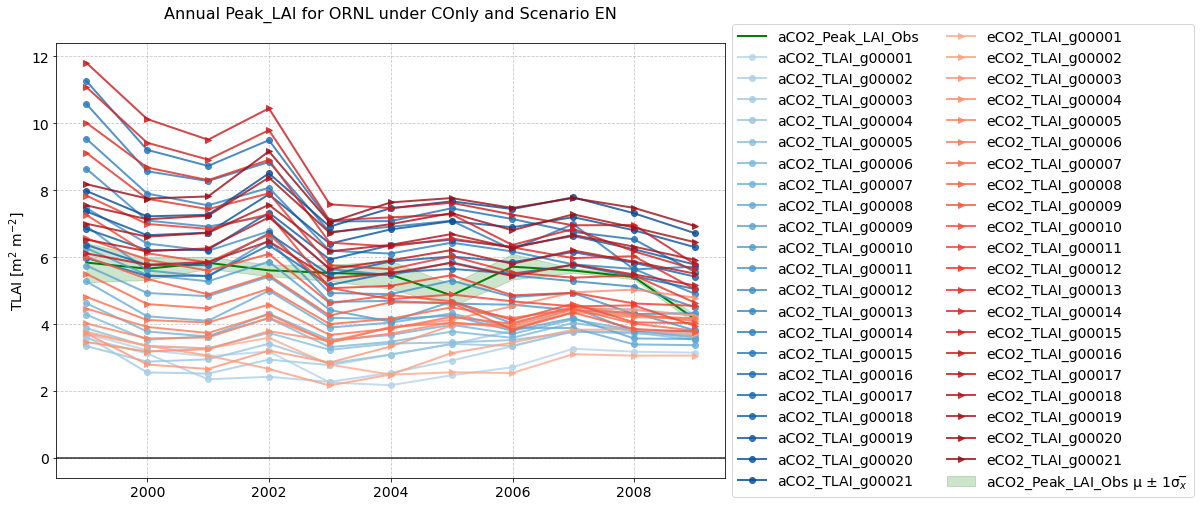

fig start RD
0 -1 aCO2
Iteration for d2bl1
index, key for var:TLAI, AnnualMean model, AnnualMean obs, d2bl1 value
0,aCO2 g00001:  3.23 vs 5.43 , 0.2
1,aCO2 g00002:  2.94 vs 5.43 , 0.22
2,aCO2 g00003:  3.4 vs 5.43 , 0.24
3,aCO2 g00004:  3.85 vs 5.43 , 0.26
4,aCO2 g00005:  3.83 vs 5.43 , 0.28
5,aCO2 g00006:  3.97 vs 5.43 , 0.3
6,aCO2 g00007:  4.21 vs 5.43 , 0.32
7,aCO2 g00008:  4.47 vs 5.43 , 0.34
8,aCO2 g00009:  4.99 vs 5.43 , 0.36
9,aCO2 g00010:  5.42 vs 5.43 , 0.38
10,aCO2 g00011:  5.62 vs 5.43 , 0.4
11,aCO2 g00012:  5.94 vs 5.43 , 0.42
12,aCO2 g00013:  6.51 vs 5.43 , 0.44
13,aCO2 g00014:  7.01 vs 5.43 , 0.46
14,aCO2 g00015:  7.36 vs 5.43 , 0.48
15,aCO2 g00016:  7.72 vs 5.43 , 0.5
16,aCO2 g00017:  8.54 vs 5.43 , 0.52
17,aCO2 g00018:  8.96 vs 5.43 , 0.54
18,aCO2 g00019:  9.77 vs 5.43 , 0.56
Iteration for d2bl1
index, key for var:TLAI, AnnualMean model, AnnualMean obs, d2bl1 value
0,eCO2 g00001:  3.5 vs 5.43 , 0.2
1,eCO2 g00002:  3.24 vs 5.43 , 0.22
2,eCO2 g00003:  3.35 vs 5.43 , 0.24
3

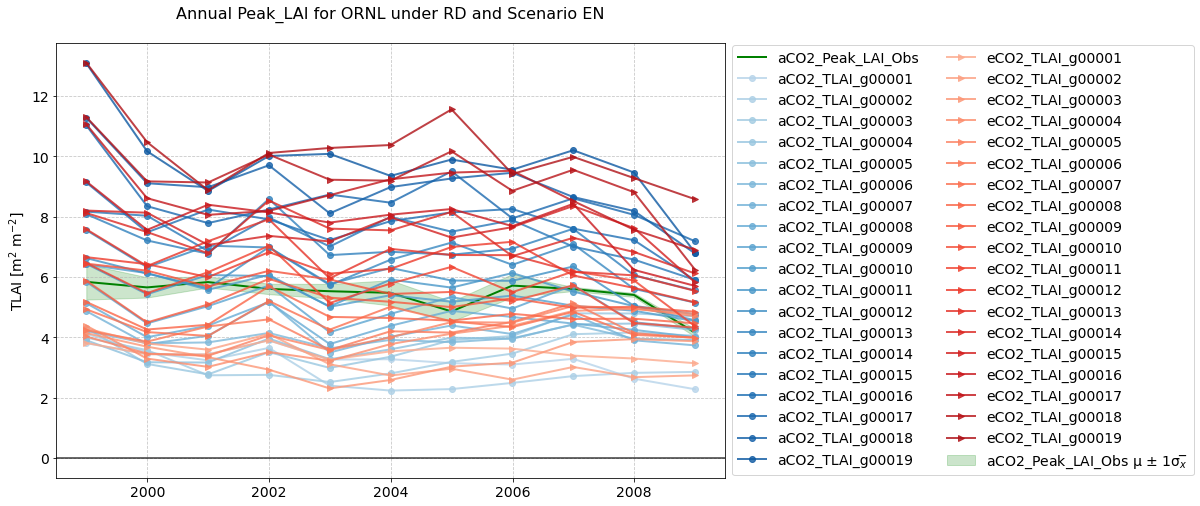

fig start ECA
0 -1 aCO2
Iteration for d2bl1
index, key for var:TLAI, AnnualMean model, AnnualMean obs, d2bl1 value
0,aCO2 g00001:  2.68 vs 5.43 , 0.2
1,aCO2 g00002:  2.82 vs 5.43 , 0.22
2,aCO2 g00003:  2.97 vs 5.43 , 0.24
3,aCO2 g00004:  3.16 vs 5.43 , 0.26
4,aCO2 g00005:  3.42 vs 5.43 , 0.28
5,aCO2 g00006:  3.49 vs 5.43 , 0.3
6,aCO2 g00007:  3.75 vs 5.43 , 0.32
7,aCO2 g00008:  4.01 vs 5.43 , 0.34
8,aCO2 g00009:  4.34 vs 5.43 , 0.36
9,aCO2 g00010:  4.71 vs 5.43 , 0.38
10,aCO2 g00011:  4.93 vs 5.43 , 0.4
11,aCO2 g00012:  5.3 vs 5.43 , 0.42
12,aCO2 g00013:  5.67 vs 5.43 , 0.44
13,aCO2 g00014:  6.1 vs 5.43 , 0.46
14,aCO2 g00015:  6.49 vs 5.43 , 0.48
15,aCO2 g00016:  7.03 vs 5.43 , 0.5
16,aCO2 g00017:  7.79 vs 5.43 , 0.52
17,aCO2 g00018:  0.05 vs 5.43 , 0.54
18,aCO2 g00019:  0.05 vs 5.43 , 0.56
19,aCO2 g00020:  10.18 vs 5.43 , 0.58
20,aCO2 g00021:  10.8 vs 5.43 , 0.6
Iteration for d2bl1
index, key for var:TLAI, AnnualMean model, AnnualMean obs, d2bl1 value
0,eCO2 g00001:  3.07 vs 5.43 , 0.

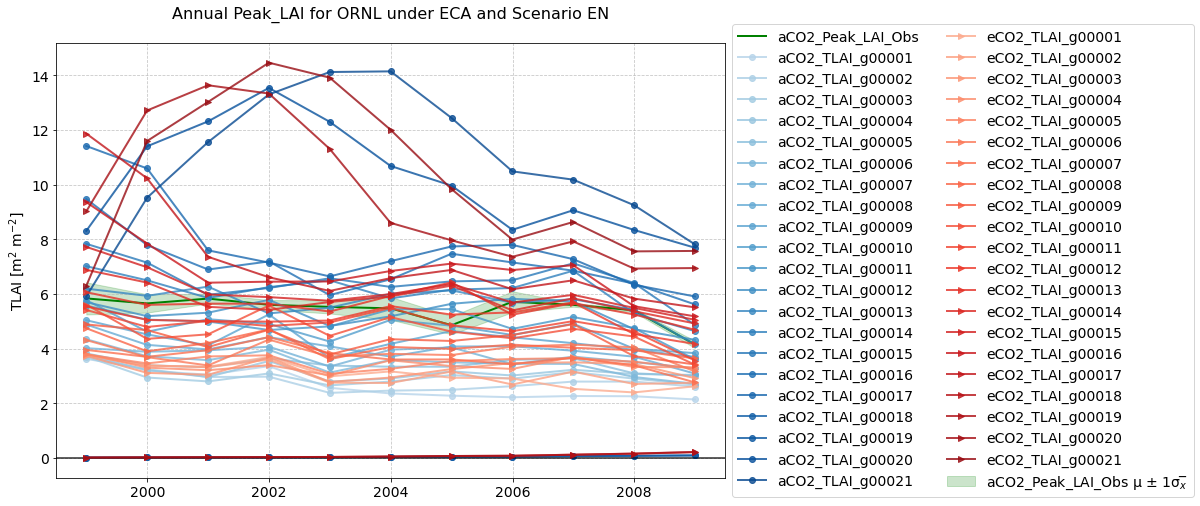

In [60]:

select_site = "US-ORN"
site = "ORNL"

data_plots[case_plot][site] = {}
data_plots_obs[site] = {}
colors_b = cm.Blues(np.linspace(0.3, 0.9, 21))  
colors_r = cm.Reds(np.linspace(0.3, 0.9, 21))  
for sim_case in sim_cases:
    data_plots[case_plot][site][sim_case] = {}
    ran_twice = 0  # Flag to track execution
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in var_names:
        data_plots[case_plot][site][sim_case][var] = {}
        data_plots_obs[site][var_obs] = {}
        bi = -1; ri=-1 # color line ndex
        oa = -1; oe = -1 # obs runs
        try:
            for idx, key in enumerate(ds.keys()):
                if sim_case not in key:
                    continue
                if (f"{site}" in key) and (f"{case_plot}_" in key): 
                    time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                    if "aCO2" in key:
                        bi=bi+1
                        oa = oa+1
                        color_line = colors_b[bi]
                        marker_line = "o"
                        co2_case = "AMB"
                        tmp_case = "aCO2"
                        color_obs = "green"
                        data_plots_obs[site][var_obs][tmp_case] = {}
                    if "eCO2" in key:
                        ri=ri+1
                        oe = oe+1
                        color_line = colors_r[ri]
                        marker_line = ">"
                        co2_case = "ELE"
                        tmp_case = "eCO2"
                        color_obs = "purple"
                        data_plots_obs[site][var_obs][tmp_case] = {}
                    #if (obs_plot ==1) and (ran_twice<2):
                    if (obs_plot ==1) and (oa<1) and (oe<1):
                        print(oa,oe,tmp_case)
                        Mean_DF = dict_obs_ax[site][co2_case]
                        Standard_error_DF = dict_obs_ase[site][co2_case]
                        # Extracting the relevant columns
                        years = Mean_DF['YEAR']
                        mean_nup = Mean_DF[f'{var_obs}']
                        se_nup = Standard_error_DF[f'{var_obs}']
                        # Plot NUP with shaded error bars
                        plt.plot(time, mean_nup, label=f'{tmp_case}_{var_obs}_Obs', color=color_obs, lw=2)
                        plt.fill_between(time, mean_nup - se_nup, mean_nup + se_nup, label=f'{tmp_case}_{var_obs}_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                        #plt.fill_between(time, mean_nup - se_nup*1.96, mean_nup + se_nup*1.96, color=color_obs, alpha=0.15)
                        data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                        data_plots_obs[site][var_obs][tmp_case]["mean_nup"] = np.array(mean_nup)
                        data_plots_obs[site][var_obs][tmp_case]["nup_1sd_lower"] = np.array(mean_nup - se_nup)
                        data_plots_obs[site][var_obs][tmp_case]["nup_1sd_upper"] = np.array(mean_nup + se_nup)
                        ran_twice +=1

                    if var == "TLAI":
                        tmp_var = ds[key]['TLAI'] 
                        plt.plot(time, tmp_var.groupby("time.year").mean(), 
                                 #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                                 label = tmp_case + "_TLAI_"+key.split('_')[-1], 
                                 color = color_line,
                                 marker = marker_line,
                                 alpha=.8, linewidth=2)
                        data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                        try:
                            
                            if int(key.split('_')[-1][-2:])-1 == 0:
                                print ("Iteration for d2bl1")
                                print ("index,",f"key for var:{var},", "AnnualMean model,", "AnnualMean obs,", "d2bl1 value")
                            print (f"{int(key.split('_')[-1][-2:])-1},{tmp_case} {key.split('_')[-1]}:  {round(float(tmp_var.groupby('time.year').mean().mean().values),2)} vs {round(mean_nup.mean(),2)}", 
                                   ",", params[f"{site}"] ["d2bl1"][int(key.split('_')[-1][-2:])-1] )
                        except:
                            pass

                    if False:
                        print (ds[key][var].long_name )
                    plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                    plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                    plt.legend(fontsize=14, ncol=2, loc='center left', bbox_to_anchor=(1, 0.5))
                    plt.ylabel(r"TLAI [m$^{2}$ m$^{-2}$]", fontsize=14)
                    plt.xticks(fontsize=14)  # Increase x-axis tick font size
                    plt.yticks(fontsize=14)  # Increase y-axis tick font size
                    #plt.ylim(1,11)
                    plt.title(f"Annual {var_obs} for {site} under {sim_case} and Scenario {case_plot}\n",fontsize=16)
                    
        except:
            pass
    print ("fig end",sim_case,site)
    print (f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.pdf")
    #plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
    #plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.png", format="png", dpi =200, bbox_inches="tight")
    plt.show()
    plt.close()

In [25]:
int(key.split('_')[-1][-2:])-1

20

In [16]:
round(mean_nup.mean(),2)

5.43

fig start COnly
Iteration for d2bl1
index, key for var:TLAI, AnnualMean model, AnnualMean obs, d2bl1 value
0,aCO2 g00001:  6.25 vs 4.85 , 0.05
1,aCO2 g00002:  6.29 vs 4.85 , 0.055
2,aCO2 g00003:  4.26 vs 4.85 , 0.06
3,aCO2 g00004:  4.78 vs 4.85 , 0.065
4,aCO2 g00005:  5.29 vs 4.85 , 0.07
5,aCO2 g00006:  5.87 vs 4.85 , 0.075
6,aCO2 g00007:  5.84 vs 4.85 , 0.08
7,aCO2 g00008:  5.86 vs 4.85 , 0.085
8,aCO2 g00009:  5.83 vs 4.85 , 0.09
9,aCO2 g00010:  5.91 vs 4.85 , 0.095
10,aCO2 g00011:  6.01 vs 4.85 , 0.1
11,aCO2 g00012:  5.9 vs 4.85 , 0.105
12,aCO2 g00013:  6.05 vs 4.85 , 0.11
13,aCO2 g00014:  6.07 vs 4.85 , 0.115
14,aCO2 g00015:  6.0 vs 4.85 , 0.12
15,aCO2 g00016:  4.97 vs 4.85 , 0.125
16,aCO2 g00017:  5.2 vs 4.85 , 0.13
17,aCO2 g00018:  5.53 vs 4.85 , 0.135
18,aCO2 g00019:  5.66 vs 4.85 , 0.14
19,aCO2 g00020:  6.01 vs 4.85 , 0.145
20,aCO2 g00021:  6.19 vs 4.85 , 0.15
Iteration for d2bl1
index, key for var:TLAI, AnnualMean model, AnnualMean obs, d2bl1 value
0,eCO2 g00001:  6.92 vs 4.85 

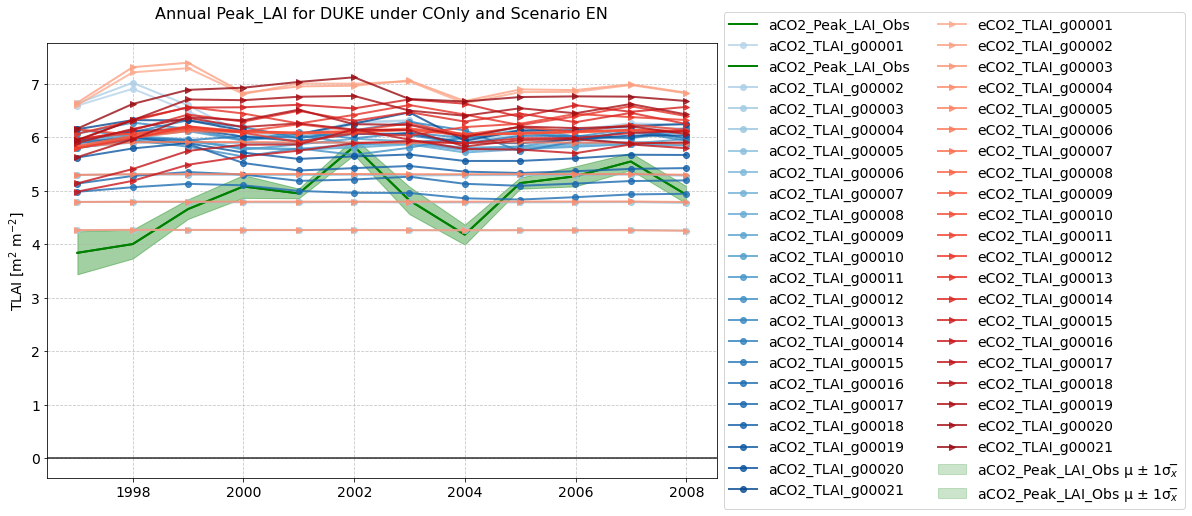

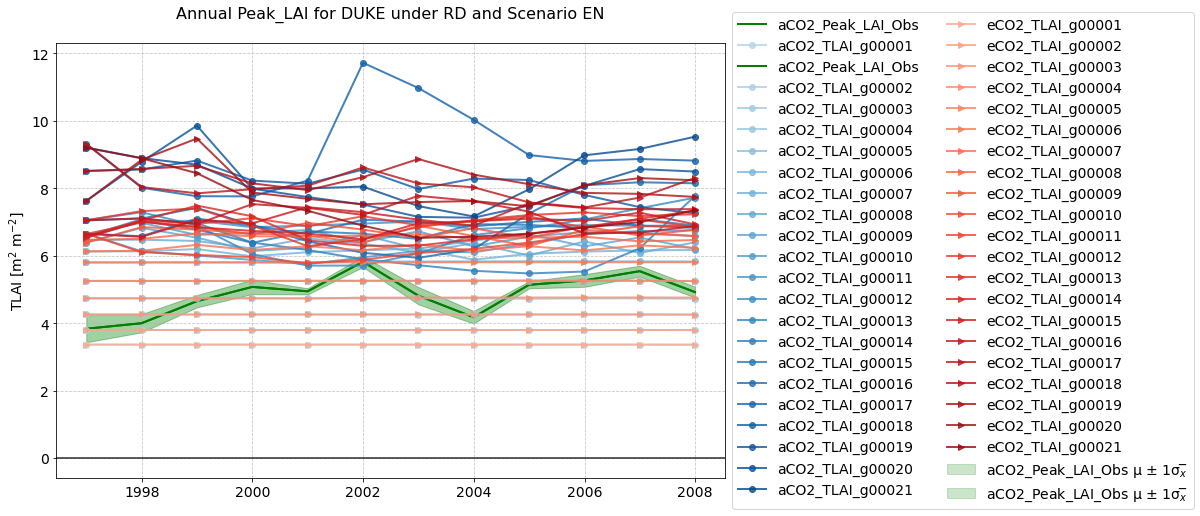

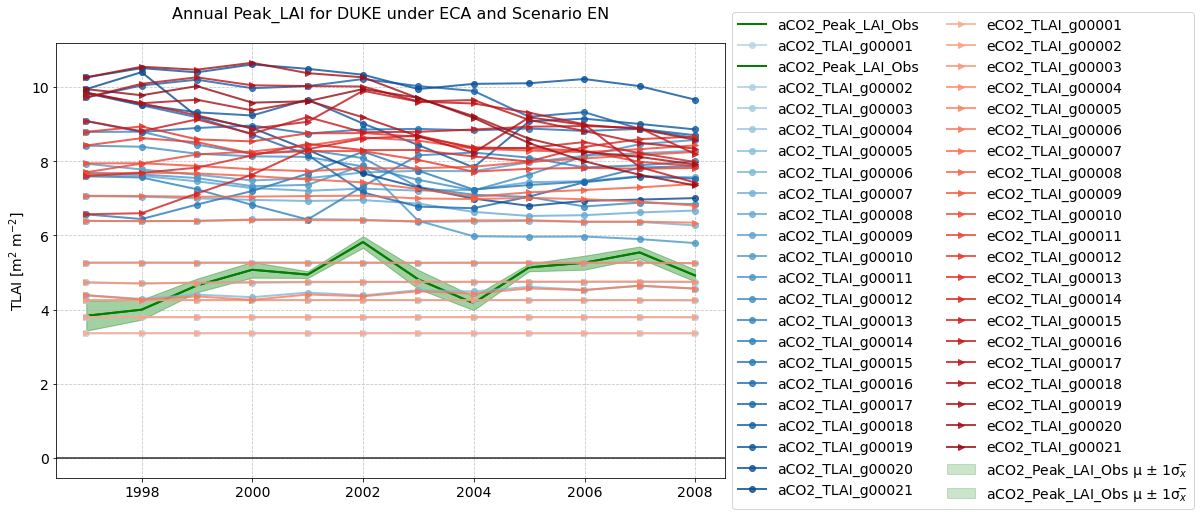

In [59]:

select_site = "US-DUK"
site = "DUKE"

data_plots[case_plot][site] = {}
data_plots_obs[site] = {}

li = 0 # for legend index
for sim_case in sim_cases:
    data_plots[case_plot][site][sim_case] = {}
    ran_twice = 0  # Flag to track execution
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in var_names:
        data_plots[case_plot][site][sim_case][var] = {}
        data_plots_obs[site][var_obs] = {}
        bi = -1; ri=-1 # color line ndex
        try:
            for idx, key in enumerate(ds.keys()):
                if sim_case not in key:
                    continue
                if (f"{site}" in key) and (f"{case_plot}_" in key): 
                    time = pd.date_range("1996-01-01", "2007-12-31", freq="A")  # Monthly data
                    if "aCO2" in key:
                        bi=bi+1
                        color_line = colors_b[bi]
                        #color_line = "b"
                        marker_line = "o"
                        co2_case = "AMB"
                        tmp_case = "aCO2"
                        color_obs = "green"
                        data_plots_obs[site][var_obs][tmp_case] = {}
                    if "eCO2" in key:
                        ri=ri+1
                        color_line = colors_r[ri]
                        #color_line = "r"
                        marker_line = ">"
                        co2_case = "ELE"
                        tmp_case = "eCO2"
                        color_obs = "purple"
                        data_plots_obs[site][var_obs][tmp_case] = {}
                    if (obs_plot ==1) and (ran_twice<2):
                        Mean_DF = dict_obs_ax[site][co2_case]
                        Standard_error_DF = dict_obs_ase[site][co2_case]
                        # Extracting the relevant columns
                        years = Mean_DF['YEAR']
                        mean_nup = Mean_DF[f'{var_obs}']
                        se_nup = Standard_error_DF[f'{var_obs}']
                        # Plot NUP with shaded error bars
                        plt.plot(time, mean_nup, label=f'{tmp_case}_{var_obs}_Obs', color=color_obs, lw=2)
                        plt.fill_between(time, mean_nup - se_nup, mean_nup + se_nup, label=f'{tmp_case}_{var_obs}_Obs μ ± 1σ$_x̅$', color=color_obs, alpha=0.2)
                        #plt.fill_between(time, mean_nup - se_nup*1.96, mean_nup + se_nup*1.96, color=color_obs, alpha=0.15)
                        ran_twice +=1
                        data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                        data_plots_obs[site][var_obs][tmp_case]["mean_nup"] = np.array(mean_nup)
                        data_plots_obs[site][var_obs][tmp_case]["nup_1sd_lower"] = np.array(mean_nup - se_nup)
                        data_plots_obs[site][var_obs][tmp_case]["nup_1sd_upper"] = np.array(mean_nup + se_nup)

                    if var == "NUP":
                        tmp_var = ( 
                            ds[key]['FATES_NH4UPTAKE'] +
                            ds[key]['FATES_NH4UPTAKE'] 
                        )*24*3600*365*1000   
                        plt.plot(time, tmp_var.groupby("time.year").mean(), 
                                 label = tmp_case + '_'+ "NUP", 
                                 color = color_line,
                                 marker = marker_line,
                                 alpha=.8, linewidth=2)
                        data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                        #plt.title(f"{var} - {key} - AnnualSUM | Units: kg m-2 yr-1\n",fontsize=14)
                    if var == "TLAI":
                        tmp_var = ds[key]['TLAI'] 
                        plt.plot(time, tmp_var.groupby("time.year").mean(), 
                                 #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                                 label = tmp_case + "_TLAI_"+key.split('_')[-1],
                                 color = color_line,
                                 marker = marker_line,
                                 alpha=.8, linewidth=2)
                        data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]
                        #print (f"{tmp_case} {key.split('_')[-1]}:  {round(float(tmp_var.groupby('time.year').mean().mean().values),2)} vs {round(mean_nup.mean(),2)}" )
                        try:
                            
                            if int(key.split('_')[-1][-2:])-1 == 0:
                                print ("Iteration for d2bl1")
                                print ("index,",f"key for var:{var},", "AnnualMean model,", "AnnualMean obs,", "d2bl1 value")
                            print (f"{int(key.split('_')[-1][-2:])-1},{tmp_case} {key.split('_')[-1]}:  {round(float(tmp_var.groupby('time.year').mean().mean().values),2)} vs {round(mean_nup.mean(),2)}", 
                                   ",", params[f"{site}"] ["d2bl1"][int(key.split('_')[-1][-2:])-1] )
                        except:
                            pass
                    if False:
                        print (ds[key][var].long_name )
                    plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                    plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                    plt.legend(fontsize=14, ncol=2, loc='center left', bbox_to_anchor=(1, 0.5))
                    plt.ylabel(r"TLAI [m$^{2}$ m$^{-2}$]", fontsize=14)
                    plt.xticks(fontsize=14)  # Increase x-axis tick font size
                    plt.yticks(fontsize=14)  # Increase y-axis tick font size
                    #plt.ylim(1,11)
                    plt.title(f"Annual {var_obs} for {site} under {sim_case} and Scenario {case_plot}\n",fontsize=16)
                    #li+=1 # for legend index updating for a site
        except:
            pass
    print ("fig end",sim_case,site)
    print (f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.pdf")
    #plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
    #plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}.png", format="png", dpi =200, bbox_inches="tight")
        
    

In [18]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# NUP Response for ORNL
select_site = "US-ORN"
site = "ORNL"
li = 0  # for legend index
tmp_case = "Response"
for sim_case in sim_cases:
    ran_once = False
    plt.figure(figsize=(12, 6))
    for var in var_names:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range(
                    "1998-01-01", "2008-12-31", freq="A"
                )  # Monthly data
                color_obs = "k"

                if (obs_plot == 1) and (not ran_once):
                    Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                    Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                    Mean_DF = (
                        Mean_DF1[["YEAR", f"{var_name_obs}"]]
                        - Mean_DF0[["YEAR", f"{var_name_obs}"]]
                    )
                    Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                    Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                        drop=True
                    )
                    Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                        drop=True
                    )

                    Standard_error_DF = (
                        (Standard_error_DF1[["YEAR", f"{var_name_obs}"]]) ** 2
                        + (Standard_error_DF0[["YEAR", f"{var_name_obs}"]]) ** 2
                    ) ** 0.5
                    Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                    

                    # Extracting the relevant columns
                    years = Mean_DF["YEAR"]
                    mean_nup = Mean_DF[f"{var_obs}"]
                    se_nup = Standard_error_DF[f"{var_obs}"]
                    # Plot NUP with shaded error bars
                    plt.plot(
                        time,
                        mean_nup,
                        label=f"Response_{var_obs}_Obs",
                        color=color_obs,
                        lw=2,
                    )
                    plt.fill_between(
                        time,
                        mean_nup - se_nup,
                        mean_nup + se_nup,
                        label=f"Response_{var_obs}_Obs μ ± 1σ$_x̅$",
                        color=color_obs,
                        alpha=0.2,
                    )
                    data_plots_obs[site][var_obs][tmp_case] = {}
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_nup"] = np.array(mean_nup)
                    data_plots_obs[site][var_obs][tmp_case]["nup_1sd_lower"] = np.array(mean_nup - se_nup)
                    data_plots_obs[site][var_obs][tmp_case]["nup_1sd_upper"] = np.array(mean_nup + se_nup)
                    #plt.fill_between(
                    #    time,
                    #    mean_nup - se_nup * 1.96,
                    #    mean_nup + se_nup * 1.96,
                    #    color=color_obs,
                    #    alpha=0.15,
                    #)

                    ran_once = True

                if "aCO2" in key:
                    color_line = "blue"
                    marker_line = "^"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var == "TLAI":
                    tmp_var_a = ds[key]["TLAI"]
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = ds[key_eCO2]["TLAI"]
                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + var,
                        color=color_line,
                        marker=marker_line,
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: kg m-2 yr-1\n",fontsize=14)
                if False:
                    print(ds[key][var].long_name)
                plt.axhline(y=0, color="k", lw=2, alpha=0.02)
                plt.grid(
                    True, linestyle="--", alpha=0.7
                )  # Dashed grid lines with better visibility
                plt.legend(fontsize=14)
                plt.ylabel(r"TLAI Response [m$^{-2}$ m$^{-2}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                #plt.ylim(-2, 8)
                plt.title(
                    f"Annual {var_obs} Response for {site} under {sim_case} and Scenario {case_plot}\n",
                    fontsize=16,
                )
                # li+=1 # for legend index updating for a sit

    print(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf"
    )
    plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf",format="pdf",bbox_inches="tight",)
    plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.png",format="png",dpi=200,bbox_inches="tight",)
    
    

In [ ]:
# NUP Response for ORNL
select_site = "US-DUK"
site = "DUKE"
li = 0  # for legend index
tmp_case = "Response"
for sim_case in sim_cases:
    ran_once = False
    plt.figure(figsize=(12, 6))
    for var in var_names:
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range(
                    "1996-01-01", "2007-12-31", freq="A"
                )  # Yearly data
                color_obs = "k"

                if (obs_plot == 1) and (not ran_once):
                    Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                    Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                    Mean_DF = (
                        Mean_DF1[["YEAR", f"{var_name_obs}"]]
                        - Mean_DF0[["YEAR", f"{var_name_obs}"]]
                    )
                    Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                    Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                        drop=True
                    )
                    Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                        drop=True
                    )

                    Standard_error_DF = (
                        (Standard_error_DF1[["YEAR", f"{var_name_obs}"]]) ** 2
                        + (Standard_error_DF0[["YEAR", f"{var_name_obs}"]]) ** 2
                    ) ** 0.5
                    Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]

                    # Extracting the relevant columns
                    years = Mean_DF["YEAR"]
                    mean_nup = Mean_DF[f"{var_obs}"]
                    se_nup = Standard_error_DF[f"{var_obs}"]
                    # Plot NUP with shaded error bars
                    plt.plot(
                        time,
                        mean_nup,
                        label=f"Response_{var_obs}_Obs",
                        color=color_obs,
                        lw=2,
                    )
                    plt.fill_between(
                        time,
                        mean_nup - se_nup,
                        mean_nup + se_nup,
                        label=f"Response_{var_obs}_Obs μ ± 1σ$_x̅$",
                        color=color_obs,
                        alpha=0.2,
                    )
                    data_plots_obs[site][var_obs][tmp_case] = {}
                    data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                    data_plots_obs[site][var_obs][tmp_case]["mean_nup"] = np.array(mean_nup)
                    data_plots_obs[site][var_obs][tmp_case]["nup_1sd_lower"] = np.array(mean_nup - se_nup)
                    data_plots_obs[site][var_obs][tmp_case]["nup_1sd_upper"] = np.array(mean_nup + se_nup)
                    #plt.fill_between(
                    #    time,
                    #    mean_nup - se_nup * 1.96,
                    #    mean_nup + se_nup * 1.96,
                    #    color=color_obs,
                    #    alpha=0.15,
                    #)

                    ran_once = True

                if "aCO2" in key:
                    color_line = "blue"
                    marker_line = "^"
                if "eCO2" in key:
                    color_line = "gray"
                    marker_line = "^"
                    continue
                if var == "TLAI":
                    tmp_var_a = ds[key]["TLAI"]
                    key_eCO2 = key.replace("aCO2", "eCO2")
                    tmp_var_e = ds[key_eCO2]["TLAI"]
                    plt.plot(
                        time,
                        (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                        label=tmp_case
                        .split("_")[-1]
                        .replace("aCO2", "Response")
                        + "_"
                        + var,
                        color=color_line,
                        marker=marker_line,
                        alpha=0.8,
                        linewidth=2,
                    )
                    data_plots[case_plot][site][sim_case][var][tmp_case] = (tmp_var_e - tmp_var_a).groupby("time.year").mean().values[:, 0]
                    # plt.title(f"{var} - {key} - AnnualSUM | Units: kg m-2 yr-1\n",fontsize=14)
                if False:
                    print(ds[key][var].long_name)
                plt.axhline(y=0, color="k", lw=2, alpha=0.02)
                plt.grid(
                    True, linestyle="--", alpha=0.7
                )  # Dashed grid lines with better visibility
                plt.legend(fontsize=14)
                plt.ylabel(r"TLAI Response [kg m$^{-2}$ yr$^{-1}$]", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                #plt.ylim(-2, 8)
                plt.title(
                    f"Annual {var_obs} Response for {site} under {sim_case} and Scenario {case_plot}\n",
                    fontsize=16,
                )
                # li+=1 # for legend index updating for a site

    print(
        f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf"
    )
    plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.pdf", format="pdf", bbox_inches="tight",)
    plt.savefig(f"{path_save_results}/{var_obs}_sce_{case_plot}_{site}_{sim_case}_Response.png", format="png", dpi=200, bbox_inches="tight",)
    